# Pràctica 2 — Anàlisi exploratòria (EDA)

**Dataset:** `data/raw/pisos_catalunya_20260405.csv` — 10.864 anuncis × 34 columnes
extrets a la P1 amb scraping de [pisos.com](https://www.pisos.com) per Catalunya.

**Objectiu d'aquest notebook:** entendre l'estructura del dataset, detectar
patrons de missing, identificar anomalies justificades per regles de domini, i
explorar la distribució de les variables candidates a target del modelat
(`price_eur`, `price_per_m2`, `area_m2`). Tota la lògica reutilitzable viu a
`src/`; el notebook només orquestra i comenta.

**Variable objectiu final:** `log(price_per_m2)`.

Totes les figures es desen automàticament a `outputs/figures/` en PNG + PDF
(DPI=200). La taula resum d'anomalies es desa a `outputs/tables/anomalies.csv`.


## 0. Setup, imports i path resolution

In [1]:
# Imports i configuració global
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

# Reproductibilitat
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estil consistent
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("No s'ha trobat pyproject.toml — el project root és desconegut")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "pisos_catalunya_20260405.csv"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Afegim project root a sys.path perquè `from src import ...` funcioni
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import cleaning, features, plots  # noqa: E402

print(f"Project root : {PROJECT_ROOT}")
print(f"CSV          : {DATA_PATH}")
print(f"Existeix     : {DATA_PATH.exists()} ({DATA_PATH.stat().st_size / 1e6:.1f} MB)")


Project root : C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia
CSV          : C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\data\raw\pisos_catalunya_20260405.csv
Existeix     : True (9.7 MB)


## 1. Càrrega del CSV

Delimiter `;`, encoding `utf-8-sig` (el BOM ve del export per defecte de
Scrapy). Forcem `dtype=str` per les columnes de coordenades i les convertim
després — així evitem que pandas perdi precisió en valors com `41.374742707`.


In [2]:
df = pd.read_csv(DATA_PATH, delimiter=";", encoding="utf-8-sig")
print(f"Shape : {df.shape}")
df.head(3)


Shape : (10864, 34)


,listing_id,title,property_type,operation,price_eur,price_per_m2,area_m2,rooms,bathrooms,floor,...,energy_cert,construction_year,condition,advertiser_name,advertiser_type,photo_count,is_new_development,url,scrape_date,scrape_timestamp
0,6.008765e+10,"Casa en venta en Carrer del Maresme, 5",Casa,venta,369000.0,1493.93,247.0,5.0,3.0,NaN,...,E,Entre 30 y 50 años,NaN,VERVIVIENDAS.COM,Agencia,88.0,False,https://www.pisos.com/comprar/casa-corbera_de_...,2026-04-05,2026-04-05T12:23:45.153203
1,6.084222e+10,"Piso en venta en Carrer d'Olzinelles, cerca de...",Piso,venta,395000.0,5064.10,78.0,3.0,2.0,Bajo,...,G,Más de 50 años,NaN,OPENLLAR SERVEIS IMMOBILIARIS,Agencia,24.0,False,https://www.pisos.com/comprar/piso-sants_montj...,2026-04-05,2026-04-05T12:23:47.224253
2,6.254910e+10,Piso en venta en Avinguda de la Diagonal,Piso,venta,360000.0,3913.04,92.0,4.0,2.0,5ª,...,E,NaN,NaN,OPENLLAR SERVEIS IMMOBILIARIS,Agencia,57.0,False,https://www.pisos.com/comprar/piso-les_bobiles...,2026-04-05,2026-04-05T12:23:50.326277


## 2. Visió general — `info()` i `describe()`

`info()` ens diu el tipus inferit per pandas i el nombre de no-nuls. Veurem
que algunes columnes booleanes vénen com a string `"True"/"False"` i caldrà
convertir-les a la fase de neteja.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10864 entries, 0 to 10863
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   listing_id            10864 non-null  float64
 1   title                 10864 non-null  object 
 2   property_type         10864 non-null  object 
 3   operation             10864 non-null  object 
 4   price_eur             10864 non-null  float64
 5   price_per_m2          10649 non-null  float64
 6   area_m2               10751 non-null  float64
 7   rooms                 10492 non-null  float64
 8   bathrooms             10498 non-null  float64
 9   floor                 4072 non-null   object 
 10  has_elevator          10864 non-null  bool   
 11  district              6627 non-null   object 
 12  neighborhood          10864 non-null  object 
 13  full_address          10864 non-null  object 
 14  locality              10859 non-null  object 
 15  latitude           

### Estadístics descriptius — numèriques

In [4]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
listing_id,10864.0,7.522511e+11,2.565725e+13,8.821499e+07,5.593277e+10,6.087723e+10,6.251806e+10,9.458569e+14
price_eur,10864.0,4.022248e+05,5.202676e+05,0.000000e+00,1.650000e+05,2.800000e+05,4.550000e+05,2.000000e+07
price_per_m2,10649.0,2.590121e+03,1.786544e+03,4.000000e-01,1.389310e+03,2.313130e+03,3.361110e+03,2.200000e+04
area_m2,10751.0,5.766360e+02,1.687978e+04,1.000000e+00,8.200000e+01,1.210000e+02,2.260000e+02,1.465248e+06
rooms,10492.0,3.443576e+00,1.734762e+00,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+01
bathrooms,10498.0,2.065441e+00,1.331285e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+01
latitude,10859.0,5.268180e+02,4.461203e+03,4.054100e+01,4.122230e+01,4.157398e+01,4.182556e+01,4.239800e+04
longitude,10859.0,4.617017e+00,8.056999e+01,2.515099e-01,1.110570e+00,1.920992e+00,2.709006e+00,3.187000e+03
photo_count,10846.0,2.940651e+01,1.913080e+01,1.000000e+00,1.600000e+01,2.600000e+01,3.800000e+01,2.010000e+02


### Estadístics descriptius — categòriques

`unique` ens dóna una primera idea de la cardinalitat de cada categòrica i
ajuda a detectar columnes degenerades (p. ex. `operation` només té el valor
`venta` perquè la P1 va filtrar per venda).


In [5]:
df.describe(include=['object', 'bool']).T

,count,unique,top,freq
title,10864,7132,Piso en venta en Centre,147
property_type,10864,8,Piso,4710
operation,10864,1,venta,10864
floor,4072,22,1ª,982
has_elevator,10864,2,False,7428
district,6627,224,Lleida Capital,523
neighborhood,10864,1242,Centre,536
full_address,10864,1299,Empuriabrava (Castelló d'Empúries),197
locality,10859,681,Barcelona Capital,612
description,10864,9745,Inmueble okupado se estudian ofertas un agente...,21


## 3. Mapa de missings

`missingno.matrix` ens mostra la matriu de presència/absència ordenada
verticalment per files; `missingno.heatmap` ens mostra la correlació entre
patrons de missing (parells de columnes que sempre estan o sempre falten
juntes).


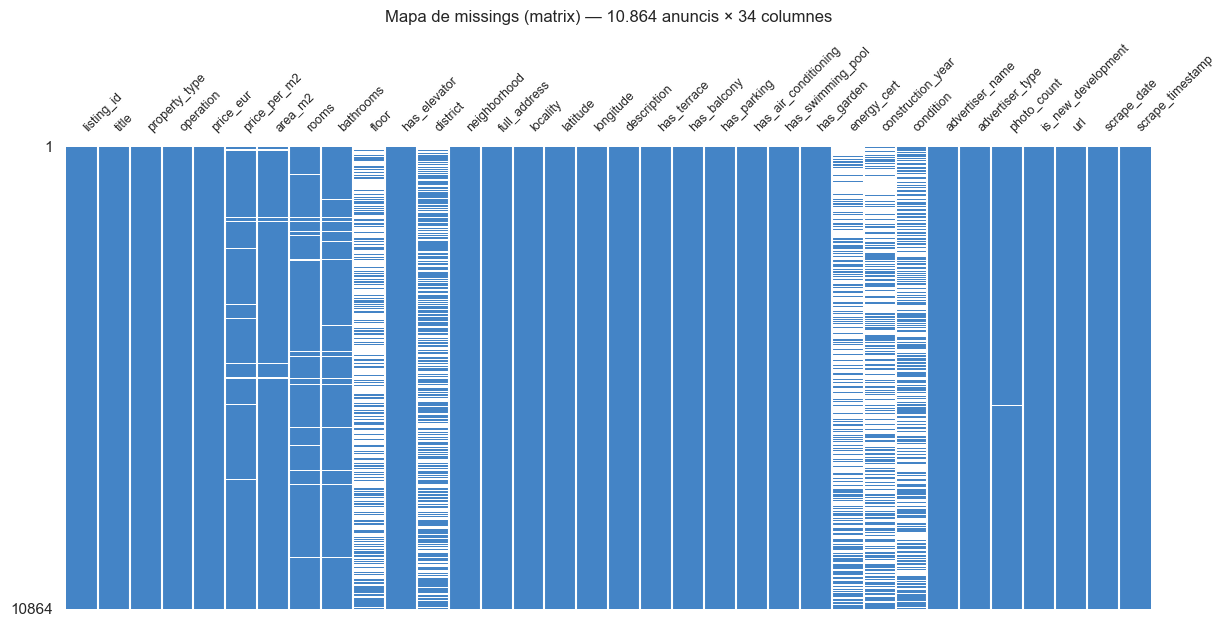

In [6]:
fig = plt.figure(figsize=(14, 6))
ax = msno.matrix(df, fontsize=9, color=(0.27, 0.52, 0.78), sparkline=False, ax=plt.gca())
ax.set_title("Mapa de missings (matrix) — 10.864 anuncis × 34 columnes",
             fontsize=12, pad=14)
plots.save_fig(fig, figures_dir=FIG_DIR, name="01_missingno_matrix")
plt.show()


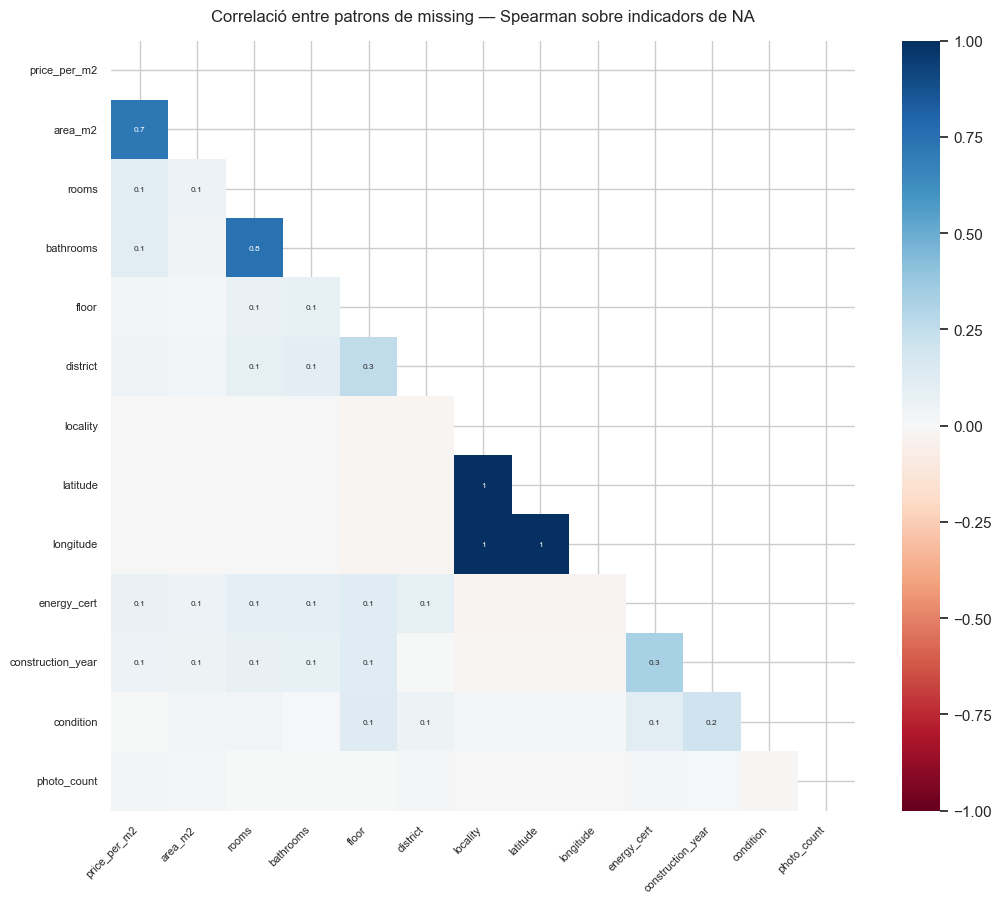

In [7]:
fig = plt.figure(figsize=(12, 10))
ax = msno.heatmap(df, fontsize=8, ax=plt.gca())
ax.set_title("Correlació entre patrons de missing — Spearman sobre indicadors de NA",
             fontsize=12, pad=14)
plots.save_fig(fig, figures_dir=FIG_DIR, name="02_missingno_heatmap")
plt.show()


In [8]:
# Conteig brut de missings per columna (top-15)
missings = df.isna().sum().sort_values(ascending=False)
missings_pct = (missings / len(df) * 100).round(2)
pd.DataFrame({"n_missing": missings, "pct": missings_pct}).head(15)


,n_missing,pct
energy_cert,7144,65.76
floor,6792,62.52
construction_year,6747,62.10
condition,5476,50.41
district,4237,39.00
rooms,372,3.42
bathrooms,366,3.37
price_per_m2,215,1.98
area_m2,113,1.04
photo_count,18,0.17


## 4. Distribucions — histogrames + Q-Q

Mirem la distribució de `price_eur`, `price_per_m2` i `area_m2` tant en
l'escala original com en logarítmica. El Q-Q plot contra una normal ens
ajuda a justificar la transformació logarítmica per a la fase de modelat
(la nostra variable objectiu serà `log(price_per_m2)`).


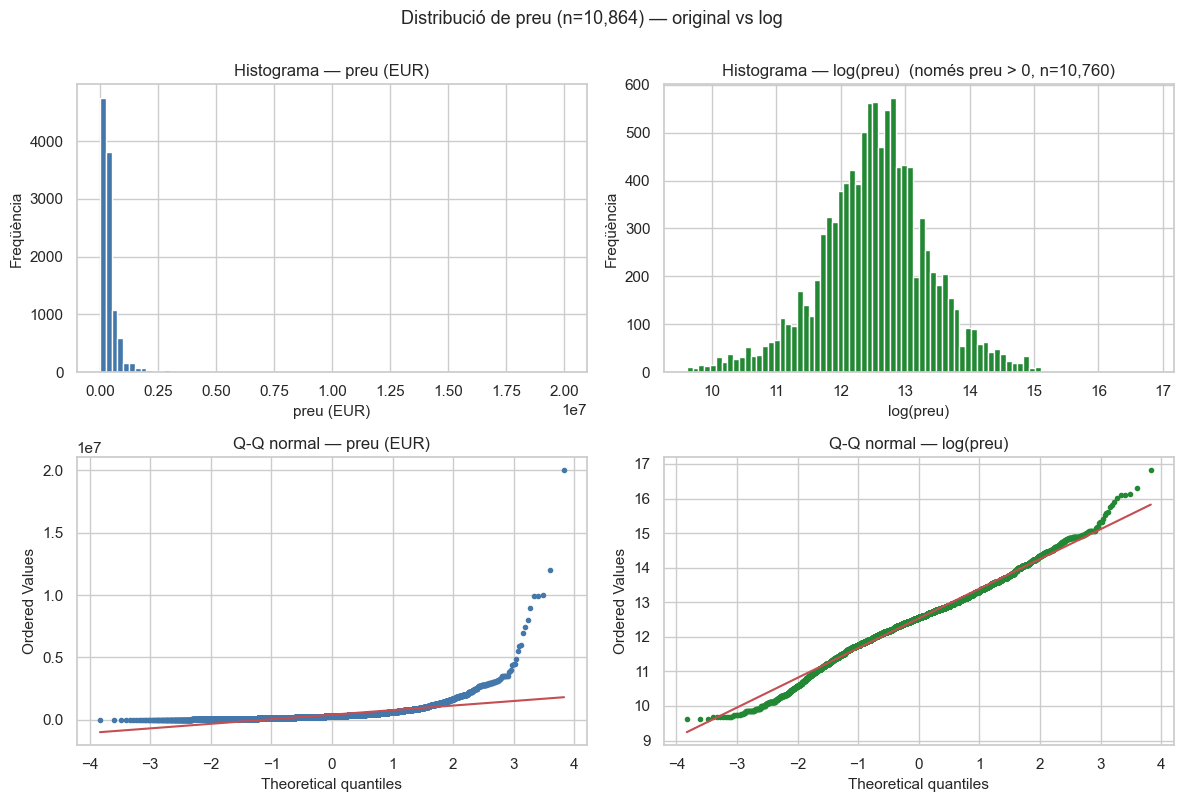

In [9]:
def plot_hist_qq(series: pd.Series, name: str, unit: str, save_name: str):
    '''Genera una graella 2x2: hist original, hist log, Q-Q original, Q-Q log.

    `series` es neteja de NaN i de valors no positius abans del log.
    '''
    s = pd.to_numeric(series, errors="coerce").dropna()
    s_pos = s[s > 0]
    s_log = np.log(s_pos)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Distribució de {name} (n={len(s):,}) — original vs log",
                 fontsize=13, y=1.00)

    # Histograma original
    axes[0, 0].hist(s, bins=80, color="#4477AA", edgecolor="white")
    axes[0, 0].set_title(f"Histograma — {name} ({unit})")
    axes[0, 0].set_xlabel(f"{name} ({unit})")
    axes[0, 0].set_ylabel("Freqüència")

    # Histograma log
    axes[0, 1].hist(s_log, bins=80, color="#228833", edgecolor="white")
    axes[0, 1].set_title(f"Histograma — log({name})  (només {name} > 0, n={len(s_pos):,})")
    axes[0, 1].set_xlabel(f"log({name})")
    axes[0, 1].set_ylabel("Freqüència")

    # Q-Q original
    stats.probplot(s, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title(f"Q-Q normal — {name} ({unit})")
    axes[1, 0].get_lines()[0].set_markerfacecolor("#4477AA")
    axes[1, 0].get_lines()[0].set_markeredgecolor("#4477AA")
    axes[1, 0].get_lines()[0].set_markersize(3)

    # Q-Q log
    stats.probplot(s_log, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f"Q-Q normal — log({name})")
    axes[1, 1].get_lines()[0].set_markerfacecolor("#228833")
    axes[1, 1].get_lines()[0].set_markeredgecolor("#228833")
    axes[1, 1].get_lines()[0].set_markersize(3)

    fig.tight_layout()
    plots.save_fig(fig, figures_dir=FIG_DIR, name=save_name)
    return fig


_ = plot_hist_qq(df["price_eur"], "preu", "EUR", "03_hist_qq_price_eur")
plt.show()


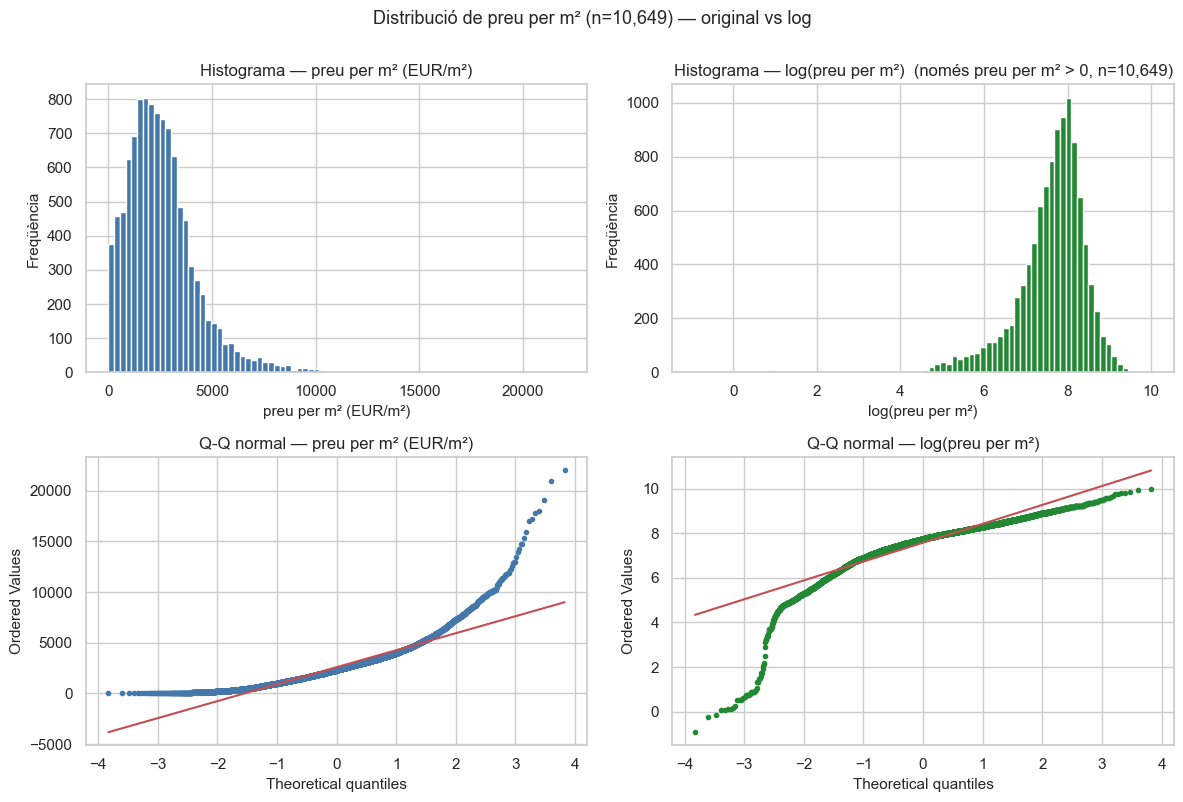

In [10]:
_ = plot_hist_qq(df["price_per_m2"], "preu per m²", "EUR/m²", "04_hist_qq_price_per_m2")
plt.show()


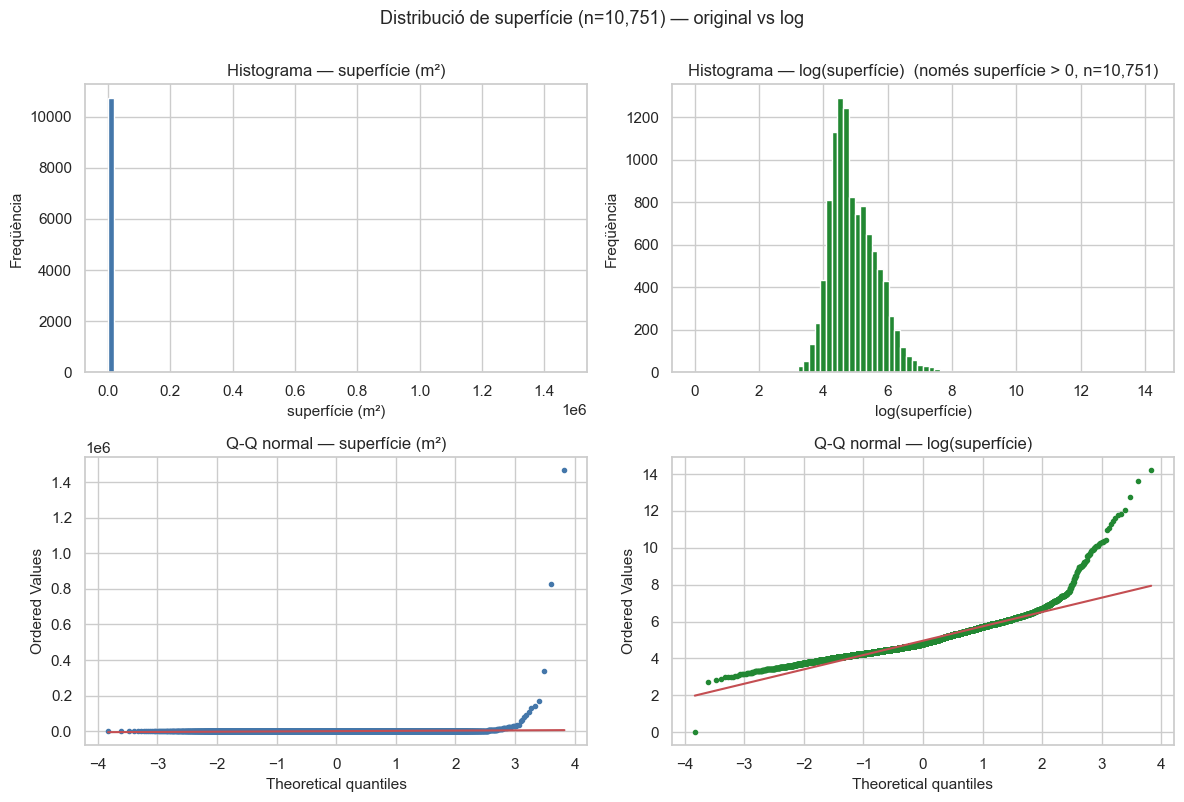

In [11]:
_ = plot_hist_qq(df["area_m2"], "superfície", "m²", "05_hist_qq_area_m2")
plt.show()


## 5. Boxplots de `price_per_m2` per categoria

Derivem `provincia` a partir de `locality` usant el diccionari curat a
`src/features.py`. Els municipis no presents al diccionari queden marcats com
`"Desconeguda"` i s'inspeccionaran després.


In [12]:
df = features.add_provincia(df)
# Inspecció ràpida del mapeig
df["provincia"].value_counts(dropna=False)


provincia
Tarragona      2888
Barcelona      2715
Girona         2711
Lleida         1621
Desconeguda     929
Name: count, dtype: int64

In [13]:
# Mostres dels primers municipis amb provincia "Desconeguda" — per ampliar el diccionari
desconeguts = (df.loc[df["provincia"] == "Desconeguda", "locality"]
                 .value_counts()
                 .head(20))
desconeguts


locality
Alguaire                     12
Palafolls                    11
Sant Andreu de Llavaneres    11
Sant Hilari Sacalm           11
Mont Ras                     11
Llinars del Vallès           11
La Bisbal del Penedès        11
Lliçà D'amunt                10
La Coma i la Pedra           10
Sarrià de Ter                10
Caldes D'estrac              10
Forallac                     10
Sant Feliu de Codines        10
Viladecavalls                10
Bigues i Riells del Fai      10
Benavent de Segrià            9
Canovelles                    9
Camarasa                      9
Ger                           8
Fontanals de Cerdanya         8
Name: count, dtype: int64

C:\Users\Gerard\AppData\Local\Temp\ipykernel_20848\2939049099.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="property_type", y="price_per_m2", order=order, ax=ax,
C:\Users\Gerard\AppData\Local\Temp\ipykernel_20848\2939049099.py:13: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\src\plots.py:29: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.savefig(png, dpi=dpi, bbox_inches="tight")


C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\src\plots.py:30: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.savefig(pdf, dpi=dpi, bbox_inches="tight")
C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


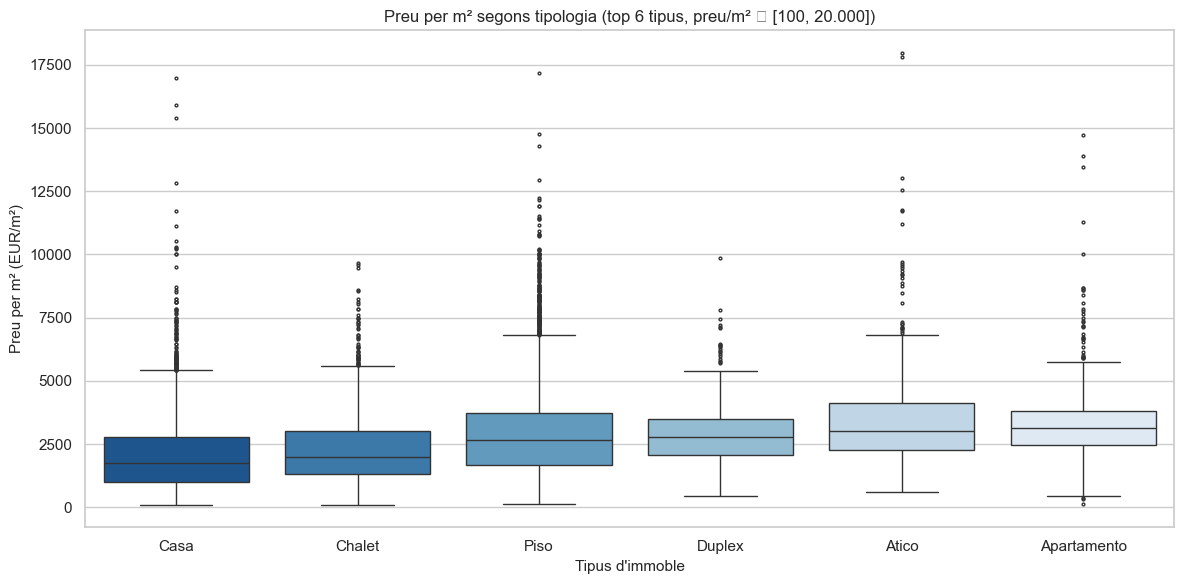

In [14]:
# Boxplot per property_type (només els 6 tipus més freqüents per llegibilitat)
top_types = df["property_type"].value_counts().head(6).index
sub = df[df["property_type"].isin(top_types) & df["price_per_m2"].between(100, 20000)]

fig, ax = plt.subplots(figsize=(12, 6))
order = sub.groupby("property_type")["price_per_m2"].median().sort_values().index
sns.boxplot(data=sub, x="property_type", y="price_per_m2", order=order, ax=ax,
            palette="Blues_r", fliersize=2)
ax.set_title("Preu per m² segons tipologia (top 6 tipus, preu/m² ∈ [100, 20.000])",
             fontsize=12)
ax.set_xlabel("Tipus d'immoble")
ax.set_ylabel("Preu per m² (EUR/m²)")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="06_boxplot_price_per_m2_by_property_type")
plt.show()


C:\Users\Gerard\AppData\Local\Temp\ipykernel_20848\190903933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_p, x="provincia", y="price_per_m2", order=order, ax=ax,
C:\Users\Gerard\AppData\Local\Temp\ipykernel_20848\190903933.py:11: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\src\plots.py:29: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.savefig(png, dpi=dpi, bbox_inches="tight")
C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\src\plots.py:30: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.savefig(pdf, dpi=dpi, bbox_inches="tight")


C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


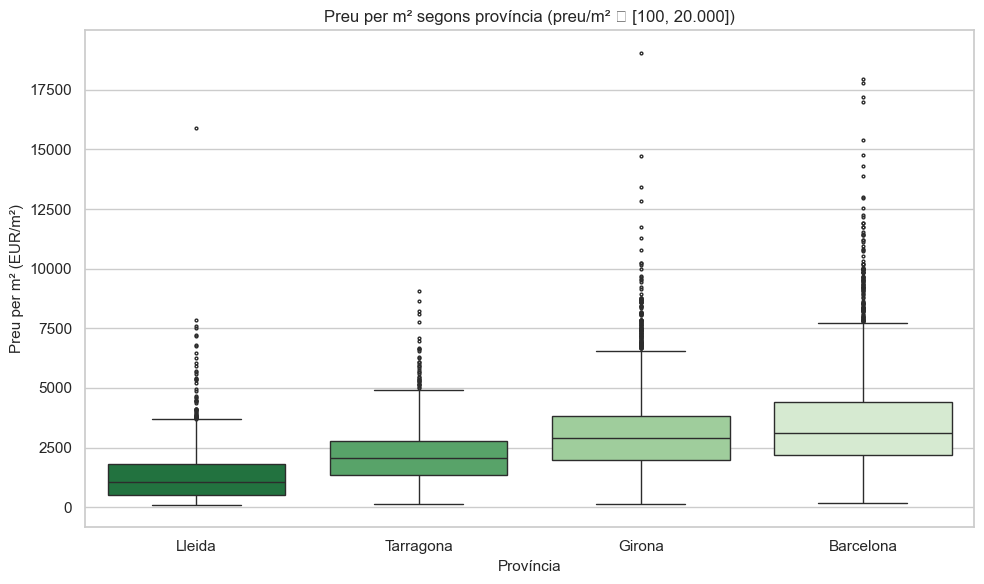

In [15]:
# Boxplot per provincia
sub_p = df[df["price_per_m2"].between(100, 20000) & (df["provincia"] != "Desconeguda")]

fig, ax = plt.subplots(figsize=(10, 6))
order = sub_p.groupby("provincia")["price_per_m2"].median().sort_values().index
sns.boxplot(data=sub_p, x="provincia", y="price_per_m2", order=order, ax=ax,
            palette="Greens_r", fliersize=2)
ax.set_title("Preu per m² segons província (preu/m² ∈ [100, 20.000])", fontsize=12)
ax.set_xlabel("Província")
ax.set_ylabel("Preu per m² (EUR/m²)")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="07_boxplot_price_per_m2_by_provincia")
plt.show()


## 6. Matriu de correlacions de Spearman

Spearman (i no Pearson) perquè algunes variables tenen distribucions molt
sesgades i la relació esperada entre p. ex. `area_m2` i `price_eur` no és
necessàriament lineal.


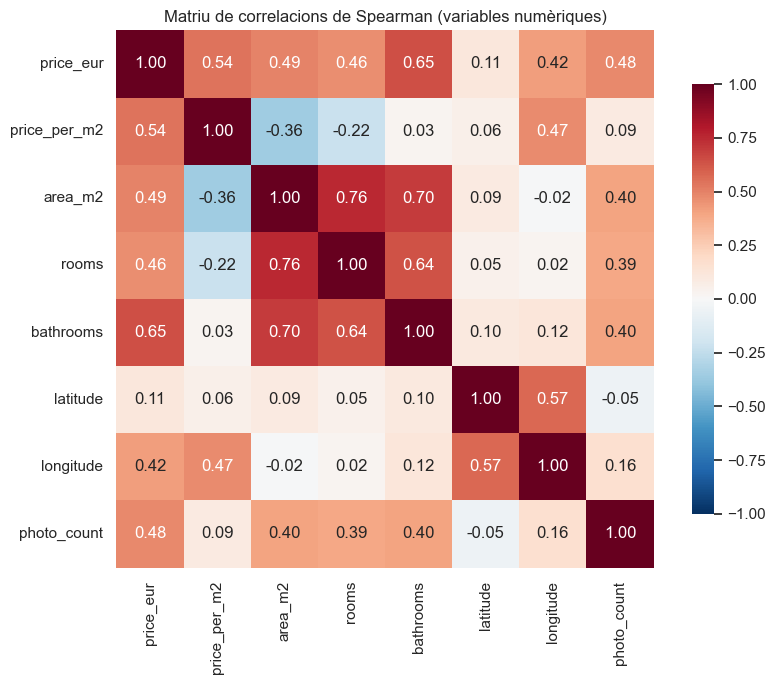

In [16]:
numeric_cols = ["price_eur", "price_per_m2", "area_m2", "rooms", "bathrooms",
                "latitude", "longitude", "photo_count"]
num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
corr = num_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriu de correlacions de Spearman (variables numèriques)", fontsize=12)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="08_spearman_corr")
plt.show()


## 7. Top-20 municipis

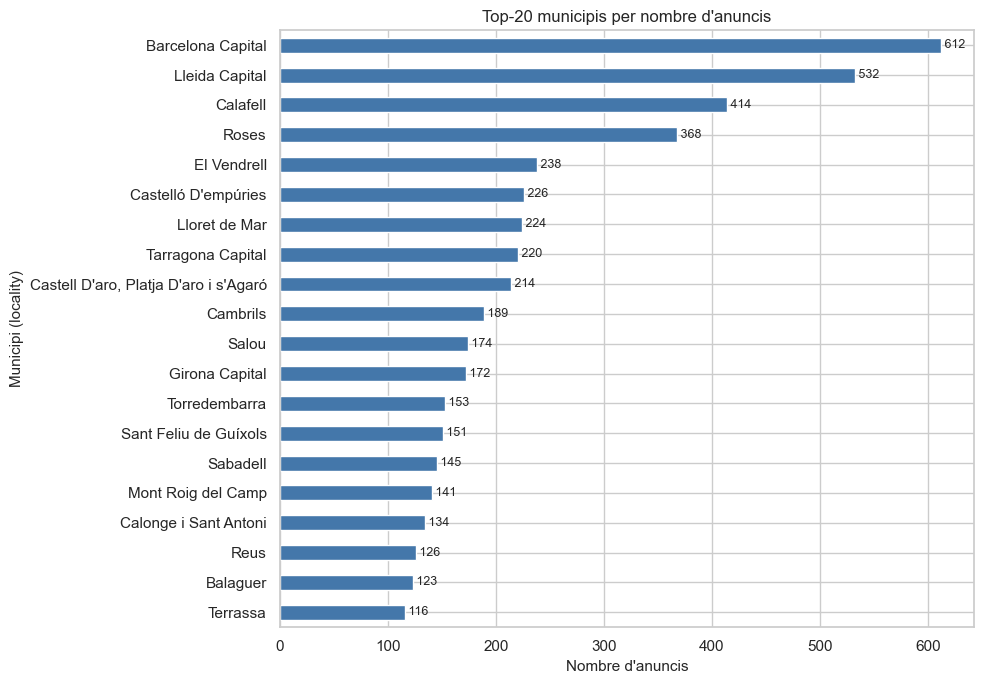

In [17]:
top20_n = df["locality"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_n.iloc[::-1].plot(kind="barh", color="#4477AA", ax=ax)
ax.set_title("Top-20 municipis per nombre d'anuncis", fontsize=12)
ax.set_xlabel("Nombre d'anuncis")
ax.set_ylabel("Municipi (locality)")
for i, v in enumerate(top20_n.iloc[::-1].values):
    ax.text(v, i, f" {v}", va="center", fontsize=9)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="09_top20_localities_count")
plt.show()


C:\Users\Gerard\AppData\Local\Temp\ipykernel_20848\2550077682.py:17: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\src\plots.py:29: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.savefig(png, dpi=dpi, bbox_inches="tight")


C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\src\plots.py:30: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.savefig(pdf, dpi=dpi, bbox_inches="tight")
C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


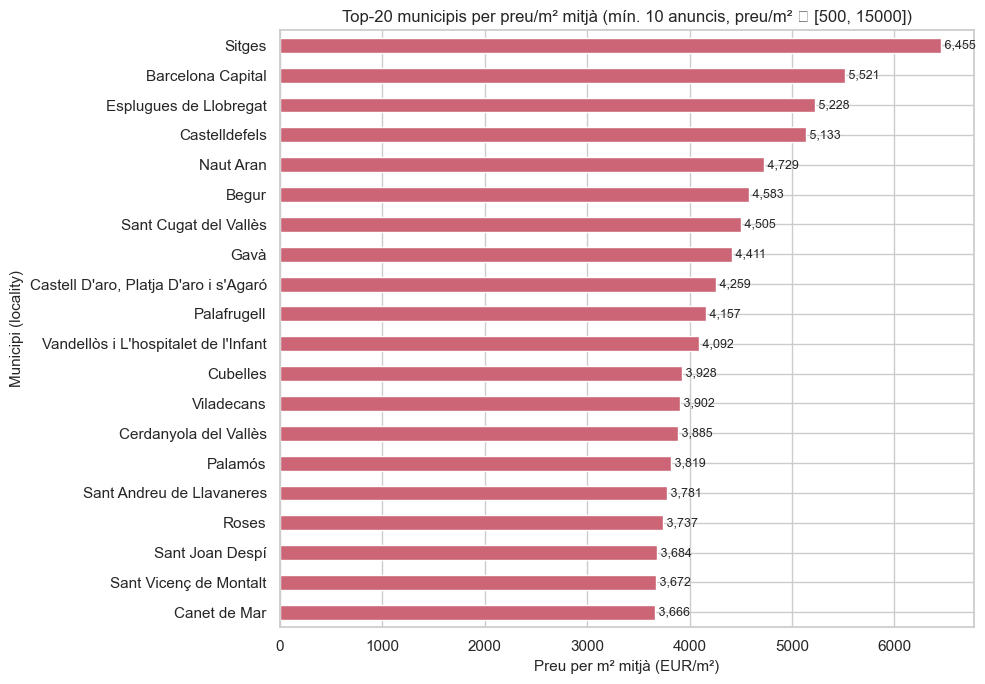

In [18]:
# Top-20 per preu/m² mitjà — filtrant municipis amb almenys 10 anuncis i preu/m² entre [500, 15000]
price_clean = df[df["price_per_m2"].between(500, 15000)]
counts = price_clean["locality"].value_counts()
elig = counts[counts >= 10].index
top20_price = (price_clean[price_clean["locality"].isin(elig)]
               .groupby("locality")["price_per_m2"].mean()
               .sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(10, 7))
top20_price.iloc[::-1].plot(kind="barh", color="#CC6677", ax=ax)
ax.set_title("Top-20 municipis per preu/m² mitjà (mín. 10 anuncis, preu/m² ∈ [500, 15000])",
             fontsize=12)
ax.set_xlabel("Preu per m² mitjà (EUR/m²)")
ax.set_ylabel("Municipi (locality)")
for i, v in enumerate(top20_price.iloc[::-1].values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="10_top20_localities_price")
plt.show()


## 8. Detecció explícita d'anomalies

Aplicació de les regles centralitzades a `src/cleaning.py`:

| Tipus              | Regla                                | Justificació                       |
|--------------------|--------------------------------------|------------------------------------|
| `lat_out_of_range` | `latitude < 40 o > 43`               | Catalunya ⊂ [40.5°N, 42.9°N] — error d'escala |
| `lon_out_of_range` | `longitude < 0 o > 4`                | Catalunya ⊂ [0.15°E, 3.33°E] — error d'escala |
| `area_huge`        | `area_m2 > 5000`                     | Probable finca rústica, no habitatge |
| `price_low`        | `0 < price_eur < 20.000`             | Sota el llindar de mercat residencial |
| `price_zero`       | `price_eur == 0`                     | "Consultar preu" — no transacció real |

La taula resum es desa a `outputs/tables/anomalies.csv` per al notebook
de neteja i per a la memòria.


In [19]:
anomalies = cleaning.detect_anomalies(df)
anomalies


,tipus,descripcio,conteig,pct
0,lat_out_of_range,"latitude fora de [40.0, 43.0] — error d'escala",127,1.169
1,price_zero,price_eur == 0 — 'consultar preu',104,0.957
2,area_huge,area_m2 > 5000 — finca rústica probable,54,0.497
3,price_low,0 < price_eur < 20000 — error de publicació pr...,39,0.359
4,lon_out_of_range,"longitude fora de [0.0, 4.0] — error d'escala",15,0.138


In [20]:
out_csv = TAB_DIR / "anomalies.csv"
anomalies.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"Desat a {out_csv}")


Desat a C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\outputs\tables\anomalies.csv


In [21]:
# Solapament entre tipus d'anomalies (matriu d'overlap)
masks = cleaning.anomaly_masks(df)
mat = pd.DataFrame({k: m for k, m in masks.items()})
overlap = mat.T.dot(mat)
overlap


,lat_out_of_range,lon_out_of_range,area_huge,price_low,price_zero
lat_out_of_range,True,True,True,False,True
lon_out_of_range,True,True,False,False,False
area_huge,True,False,True,True,True
price_low,False,False,True,True,False
price_zero,True,False,True,False,True


## 9. Conclusions de l'EDA

- **Dataset:** 10.864 anuncis × 34 columnes. Els camps del *llistat* (preu,
  superfície, habitacions, coordenades, `locality`, `has_elevator`,
  `advertiser_name`) tenen cobertura del 96-100%. Els camps de *detall*
  (`energy_cert` 34%, `construction_year` 38%, `condition` 50%) tenen molts
  missings perquè la P1 es va executar majoritàriament en mode ràpid (sense
  `--with-details`). El camp `district` cobreix només Barcelona i grans
  ciutats (61%).

- **Distribucions:** `price_eur` i `price_per_m2` són fortament esbiaixades a
  la dreta (skew ≈ 2 en escala original). La transformació logarítmica les
  acosta a una normal — el Q-Q de `log(price_per_m2)` és gairebé recte al
  cos central de la distribució, amb desviacions a les cues (perfilen els
  anuncis amb `price_eur == 0` i els price_low). Es justifica
  `log(price_per_m2)` com a variable objectiu del modelat.

- **Anomalies (taula `outputs/tables/anomalies.csv`):** 5 categories
  detectades, totes < 1.2% del total. Les coordenades fora d'escala (127
  casos) probablement es poden recuperar amb correccions de format (factor
  10 o 100) abans de descartar; `price_zero` (104) i `price_low` (39) cal
  excloure'ls del modelat per no contaminar la variable objectiu. Els 54
  immobles amb area_m2 > 5.000 m² són gairebé tots finques rústiques o
  parcel·les: convé separar-los a la fase de neteja.

- **Geografia:** distribució relativament equilibrada entre Tarragona,
  Barcelona i Girona (~1.900-2.300 anuncis cadascuna); Lleida té menys
  presència (~1.075). Un ~8.5% dels municipis no es mapegen al diccionari
  curat — cua llarga de municipis petits que s'ampliaran a la fase de
  neteja. Convindrà estratificar el train/test split per província.

- **Correlacions Spearman:** `area_m2` correlaciona força amb `price_eur`
  (com s'esperaria) però poc amb `price_per_m2` — bona senyal que el preu/m²
  capta l'efecte ubicació independent de la mida.

- **Següent pas (FASE 2):** neteja explícita (eliminar
  price_zero/price_low/area_huge, recuperar coordenades fora d'escala),
  feature engineering (afegir antiguitat numèrica a partir de
  `construction_year`, codificar `energy_cert` com a ordinal A-G), expansió
  del diccionari municipi→província, i baseline de regressió sobre
  `log(price_per_m2)`.
